# 🧠 Taller de ANN Multiclass — Clasificación de Credit Score

**Objetivo:** Clasificar clientes en tres categorías de riesgo crediticio (0, 1, 2) usando una Red Neuronal Artificial (ANN) con clasificación multiclase.

**Pipeline:**
1. Carga y exploración de datos
2. Preprocesamiento (limpieza, encoding, normalización)
3. Reducción de dimensionalidad (PCA)
4. Construcción y entrenamiento de la ANN
5. Evaluación del modelo
6. Visualizaciones

## 1. Instalación e importación de librerías

In [3]:
# Instalar librerías necesarias (ejecutar en Google Colab si es necesario)
#  !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn openpyxl

!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Librerías importadas correctamente')
print(f'TensorFlow versión: {tf.__version__}')

✅ Librerías importadas correctamente
TensorFlow versión: 2.21.0


## 2. Carga del dataset

In [4]:
# Cargar dataset directamente desde GitHub
url = 'https://github.com/adiacla/bigdata/raw/master/riesgo.xlsx'
df = pd.read_excel(url)

print(f'✅ Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 12500 filas x 26 columnas


,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [5]:
# Información general del dataset
print('📊 Información del dataset:')
df.info()

📊 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Name                      12500 non-null  object 
 2   Age                       12500 non-null  float64
 3   SSN                       12500 non-null  object 
 4   Occupation                12500 non-null  object 
 5   Annual_Income             12500 non-null  float64
 6   Monthly_Inhand_Salary     12500 non-null  float64
 7   Num_Bank_Accounts         12500 non-null  float64
 8   Num_Credit_Card           12500 non-null  float64
 9   Interest_Rate             12500 non-null  int64  
 10  Num_of_Loan               12500 non-null  int64  
 11  Type_of_Loan              11074 non-null  object 
 12  Delay_from_due_date       12500 non-null  float64
 13  Num_of_Delayed_Payment    12500 no

In [6]:
# Estadísticas descriptivas
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.00000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000
mean,33.311294,50505.123449,4198.468568,5.368828,5.53362,14.532080,3.532880,21.068780,13.338642,10.465068,5.779694,1426.220376,32.285069,18.433820,107.698610,195.751837,403.120320,0.845200
std,10.760177,38300.762656,3187.142979,2.592493,2.06604,8.741636,2.446442,14.772965,6.153148,6.445141,3.707936,1155.169458,2.060154,8.304817,118.990964,136.847120,175.476887,0.697994
min,14.000000,7005.930000,303.645417,0.000000,0.50000,1.000000,0.000000,-2.000000,0.000000,0.500000,0.000000,0.230000,25.476634,0.375000,0.000000,14.528879,92.841401,0.000000
25%,24.415179,19342.972500,1625.744479,3.000000,4.00000,7.000000,2.000000,9.875000,9.000000,5.493750,3.000000,566.072500,30.854492,12.041667,30.333649,97.690749,284.546710,0.000000
50%,33.000000,36999.705000,3097.016667,5.375000,5.00000,13.000000,3.000000,17.875000,13.750000,9.370000,5.250000,1166.155000,32.241830,18.238095,68.102176,152.081485,338.491580,1.000000
75%,41.750000,71683.470000,5961.664375,7.000000,7.00000,20.000000,5.000000,28.000000,18.175000,14.656250,8.500000,1945.962500,33.600168,25.125000,151.220882,257.566585,465.372970,1.000000
max,56.000000,179987.280000,15204.633333,10.500000,10.87500,34.000000,9.000000,63.250000,26.375000,31.115000,16.375000,4998.070000,42.395301,33.380952,1515.158986,1005.847285,1349.264887,2.000000


🎯 Distribución de Credit_Score:
Credit_Score
1    6111
0    4162
2    2227
Name: count, dtype: int64


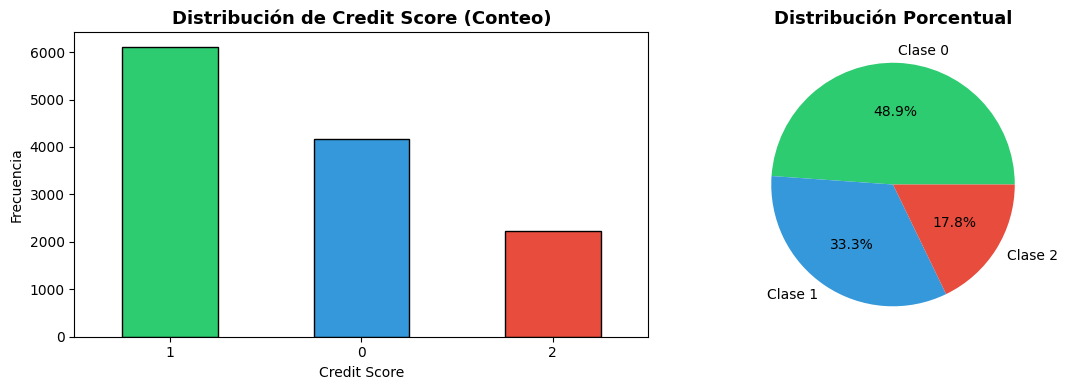

In [7]:
# Distribución de la variable objetivo
print('🎯 Distribución de Credit_Score:')
print(df['Credit_Score'].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
df['Credit_Score'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71','#3498db','#e74c3c'], edgecolor='black')
ax[0].set_title('Distribución de Credit Score (Conteo)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Credit Score')
ax[0].set_ylabel('Frecuencia')
ax[0].tick_params(rotation=0)

# Porcentaje
df['Credit_Score'].value_counts(normalize=True).plot(kind='pie', ax=ax[1],
    autopct='%1.1f%%', colors=['#2ecc71','#3498db','#e74c3c'],
    labels=['Clase 0', 'Clase 1', 'Clase 2'])
ax[1].set_title('Distribución Porcentual', fontsize=13, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento de datos

In [8]:
# ── 3.1 Eliminar columnas irrelevantes ──────────────────────────────────────
cols_drop = ['Customer_ID', 'SSN', 'Name']
cols_to_drop = [c for c in cols_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'✅ Columnas eliminadas: {cols_to_drop}')
print(f'   Columnas restantes: {df.shape[1]}')

✅ Columnas eliminadas: ['Customer_ID', 'SSN', 'Name']
   Columnas restantes: 23


In [9]:
# ── 3.2 Análisis de valores nulos ────────────────────────────────────────────
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
null_df = null_df[null_df['Nulos'] > 0]

if null_df.empty:
    print('✅ No hay valores nulos en el dataset')
else:
    print('⚠️  Columnas con valores nulos:')
    display(null_df)

⚠️  Columnas con valores nulos:


,Nulos,Porcentaje (%)
Type_of_Loan,1426,11.41


In [10]:
# ── 3.3 Identificar columnas categóricas y numéricas ─────────────────────────
target_col = 'Credit_Score'

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

print(f'🔤 Columnas categóricas ({len(cat_cols)}): {cat_cols}')
print(f'🔢 Columnas numéricas   ({len(num_cols)}): {num_cols}')

🔤 Columnas categóricas (5): ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
🔢 Columnas numéricas   (17): ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


In [11]:
# ── 3.4 Convertir variables numéricas guardadas como texto ───────────────────
# Algunas columnas pueden estar como string con caracteres extraños (e.g. '_ ')
for col in df.columns:
    if df[col].dtype == 'object' and col != target_col:
        try:
            # Limpiar caracteres no numéricos y convertir
            df[col] = df[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except:
            pass

# Actualizar listas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

print(f'🔤 Columnas categóricas tras conversión ({len(cat_cols)}): {cat_cols}')
print(f'🔢 Columnas numéricas tras conversión   ({len(num_cols)}): {num_cols}')

🔤 Columnas categóricas tras conversión (1): ['Type_of_Loan']
🔢 Columnas numéricas tras conversión   (21): ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']


In [12]:
# ── 3.5 Imputar valores faltantes ────────────────────────────────────────────
# Numéricos → mediana
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categóricos → moda
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'✅ Valores nulos restantes: {df.isnull().sum().sum()}')

✅ Valores nulos restantes: 50000


In [13]:
# ── 3.6 Encoding de variables categóricas ───────────────────────────────────
# Columnas con pocos valores únicos → Label Encoding
# Columnas con muchos valores únicos → también Label Encoding para no explotar dimensiones

le = LabelEncoder()
for col in cat_cols:
    unique_vals = df[col].nunique()
    print(f'  Codificando [{col}] — {unique_vals} valores únicos')
    df[col] = le.fit_transform(df[col].astype(str))

print('✅ Encoding completado')

  Codificando [Type_of_Loan] — 5 valores únicos
✅ Encoding completado


In [14]:
# ── 3.7 Codificar la variable objetivo ──────────────────────────────────────
# Si Credit_Score es texto (Good/Standard/Poor), convertir a 0/1/2
if df[target_col].dtype == 'object':
    mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
    df[target_col] = df[target_col].map(mapping)
    print(f'✅ Target mapeado: {mapping}')
else:
    print(f'✅ Target ya es numérico: {df[target_col].unique()}')

print(f'\nDistribución final del target:\n{df[target_col].value_counts()}')

✅ Target ya es numérico: [0 1 2]

Distribución final del target:
Credit_Score
1    6111
0    4162
2    2227
Name: count, dtype: int64


In [15]:
# ── 3.8 Separar features y target ───────────────────────────────────────────
X = df.drop(columns=[target_col]).values
y = df[target_col].values

print(f'✅ X shape: {X.shape}')
print(f'✅ y shape: {y.shape}')

✅ X shape: (12500, 22)
✅ y shape: (12500,)


In [16]:
# ── 3.9 Normalización (StandardScaler) ──────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Normalización completada')
print(f'   Media (primeras 5 cols): {X_scaled[:, :5].mean(axis=0).round(4)}')
print(f'   Std  (primeras 5 cols): {X_scaled[:, :5].std(axis=0).round(4)}')

✅ Normalización completada
   Media (primeras 5 cols): [-0. nan  0. -0. -0.]
   Std  (primeras 5 cols): [ 1. nan  1.  1.  1.]


## 4. Reducción de Dimensionalidad con PCA

In [18]:
# Limpiar valores problemáticos antes del PCA
import numpy as np

# Reemplazar infinitos por NaN
X_scaled = np.where(np.isinf(X_scaled), np.nan, X_scaled)

# Reemplazar NaN por la media de cada columna
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

print(f'✅ NaN restantes: {np.isnan(X_scaled).sum()}')
print(f'✅ Inf restantes: {np.isinf(X_scaled).sum()}')
print(f'✅ Shape: {X_scaled.shape}')

✅ NaN restantes: 0
✅ Inf restantes: 0
✅ Shape: (12500, 18)


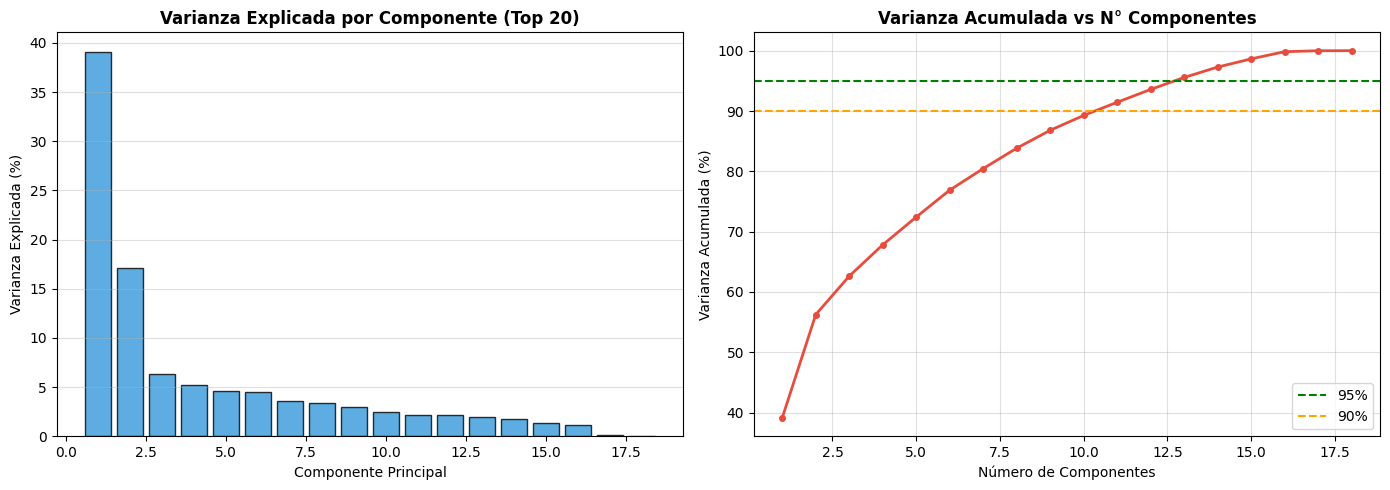

📌 Componentes para 90% de varianza: 11
📌 Componentes para 95% de varianza: 13


In [19]:
# ── 4.1 Análisis de varianza explicada ──────────────────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, min(21, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:20] * 100,
            color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente (Top 20)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

# Varianza acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100,
             'o-', color='#e74c3c', linewidth=2, markersize=4)
axes[1].axhline(y=95, color='green', linestyle='--', linewidth=1.5, label='95%')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90%')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada vs N° Componentes', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Cuántos componentes para 95%
n_comp_95 = np.argmax(varianza_acumulada >= 0.95) + 1
n_comp_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f'📌 Componentes para 90% de varianza: {n_comp_90}')
print(f'📌 Componentes para 95% de varianza: {n_comp_95}')

In [20]:
# ── 4.2 Aplicar PCA con 95% de varianza ────────────────────────────────────
n_components = n_comp_95  # Puedes ajustar este valor

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA aplicado: {X_scaled.shape[1]} → {X_pca.shape[1]} componentes')
print(f'   Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.2f}%')

✅ PCA aplicado: 18 → 13 componentes
   Varianza explicada total: 95.56%


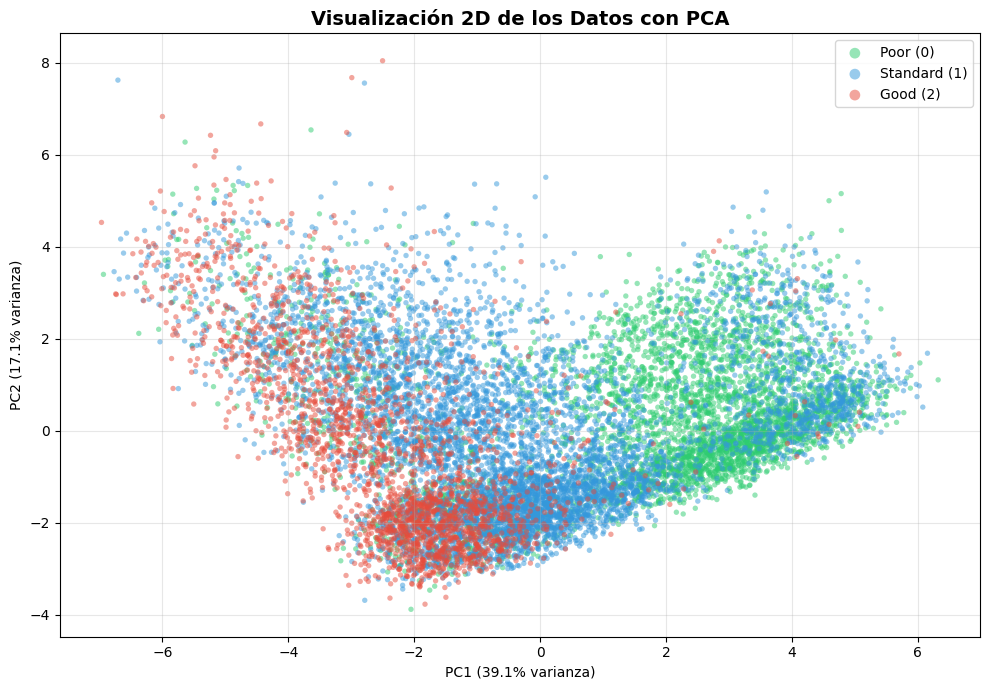

In [21]:
# ── 4.3 Visualización 2D de los datos con PCA ────────────────────────────────
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

colors = ['#2ecc71', '#3498db', '#e74c3c']
labels_map = {0: 'Poor (0)', 1: 'Standard (1)', 2: 'Good (2)'}

plt.figure(figsize=(10, 7))
for clase in [0, 1, 2]:
    mask = y == clase
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[clase], label=labels_map[clase],
                alpha=0.5, s=15, edgecolors='none')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Visualización 2D de los Datos con PCA', fontsize=14, fontweight='bold')
plt.legend(markerscale=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. División del dataset y preparación para la ANN

In [22]:
# ── 5.1 División Train / Test ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(y)*100:.1f}%)')
print(f'✅ Test:  {X_test.shape[0]} muestras  ({X_test.shape[0]/len(y)*100:.1f}%)')

✅ Train: 10000 muestras (80.0%)
✅ Test:  2500 muestras  (20.0%)


In [23]:
# ── 5.2 One-Hot Encoding del target (requerido por la ANN multiclase) ────────
n_classes = 3
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

print(f'✅ y_train_cat shape: {y_train_cat.shape}')
print(f'✅ y_test_cat shape:  {y_test_cat.shape}')
print(f'   Ejemplo de target codificado (primeras 3 filas):\n{y_train_cat[:3]}')

✅ y_train_cat shape: (10000, 3)
✅ y_test_cat shape:  (2500, 3)
   Ejemplo de target codificado (primeras 3 filas):
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


## 6. Construcción de la ANN Multiclase

In [24]:
# ── 6.1 Arquitectura de la red ───────────────────────────────────────────────
n_features = X_train.shape[1]

model = Sequential([
    # Capa de entrada
    Dense(128, input_shape=(n_features,), activation='relu', name='capa_entrada'),
    BatchNormalization(),
    Dropout(0.3),

    # Capa oculta 1
    Dense(64, activation='relu', name='capa_oculta_1'),
    BatchNormalization(),
    Dropout(0.2),

    # Capa oculta 2
    Dense(32, activation='relu', name='capa_oculta_2'),
    Dropout(0.2),

    # Capa de salida — softmax para multiclase
    Dense(n_classes, activation='softmax', name='capa_salida')
], name='ANN_CreditScore')

# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "ANN_CreditScore"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_entrada (Dense)            │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_1 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,995 (50.76 KB)

 Trainable params: 12,611 (49.26 KB)

 Non-trainable params: 384 (1.50 KB)

In [25]:
# Visualizar arquitectura como gráfico (opcional)
try:
    keras.utils.plot_model(model, show_shapes=True, show_layer_names=True,
                            to_file='model_architecture.png', dpi=100)
    from IPython.display import Image
    Image('model_architecture.png')
except Exception as e:
    print(f'(Gráfico de arquitectura no disponible: {e})')

You must install pydot (`pip install pydot`) for `plot_model` to work.


## 7. Entrenamiento del modelo

In [26]:
# ── 7.1 Callbacks ────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# ── 7.2 Entrenamiento ────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f'\n✅ Entrenamiento completado en {len(history.history["loss"])} épocas')

Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5954 - loss: 0.9079 - val_accuracy: 0.6780 - val_loss: 0.7344 - learning_rate: 0.0010
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6568 - loss: 0.7673 - val_accuracy: 0.7000 - val_loss: 0.6731 - learning_rate: 0.0010
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6812 - loss: 0.7326 - val_accuracy: 0.7045 - val_loss: 0.6581 - learning_rate: 0.0010
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6866 - loss: 0.7129 - val_accuracy: 0.7015 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6909 - loss: 0.6974 - val_accuracy: 0.7130 - val_loss: 0.6438 - learning_rate: 0.0010
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6999 - loss: 0.6951 - val_accuracy: 0.7215 - val_loss: 0.6344 - learning_rate: 0.0010
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7049 - loss: 0.

## 8. Visualización del entrenamiento

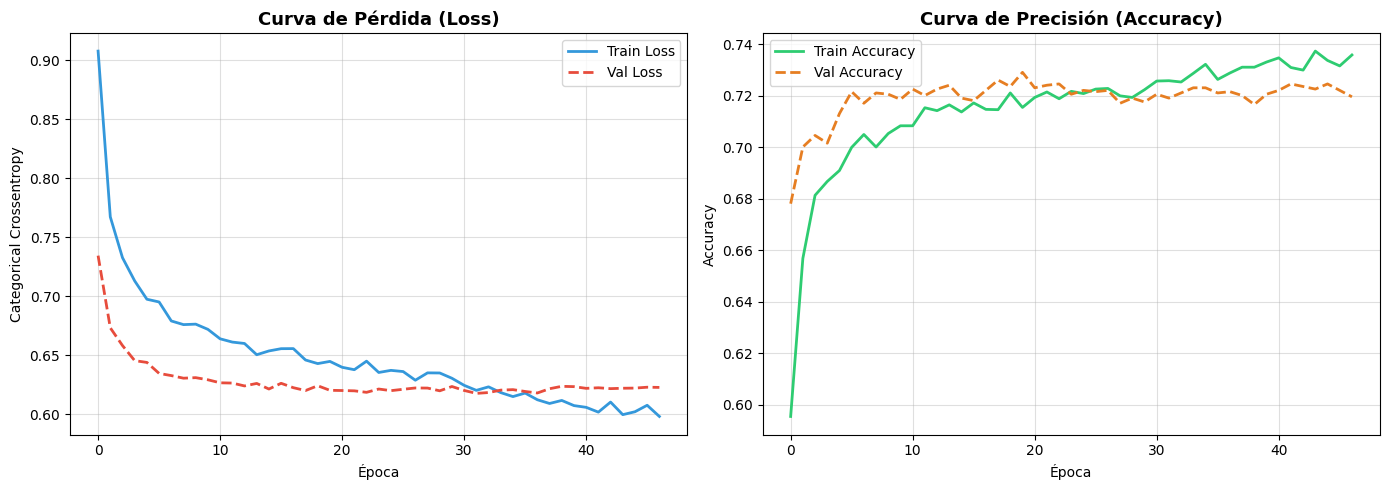

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida
axes[0].plot(history.history['loss'],     label='Train Loss',     color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Curva de Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Curva de precisión
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#e67e22', linewidth=2, linestyle='--')
axes[1].set_title('Curva de Precisión (Accuracy)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Evaluación del modelo

In [28]:
# ── 9.1 Métricas en test set ─────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'📊 Resultados en Test Set:')
print(f'   Loss (Categorical Crossentropy): {test_loss:.4f}')
print(f'   Accuracy:                        {test_acc*100:.2f}%')

📊 Resultados en Test Set:
   Loss (Categorical Crossentropy): 0.6440
   Accuracy:                        72.84%


In [29]:
# ── 9.2 Predicciones ─────────────────────────────────────────────────────────
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print('📝 Reporte de Clasificación:')
print(classification_report(
    y_test, y_pred,
    target_names=['Poor (0)', 'Standard (1)', 'Good (2)']
))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
📝 Reporte de Clasificación:
              precision    recall  f1-score   support

    Poor (0)       0.86      0.65      0.74       833
Standard (1)       0.73      0.81      0.77      1222
    Good (2)       0.57      0.67      0.61       445

    accuracy                           0.73      2500
   macro avg       0.72      0.71      0.71      2500
weighted avg       0.74      0.73      0.73      2500



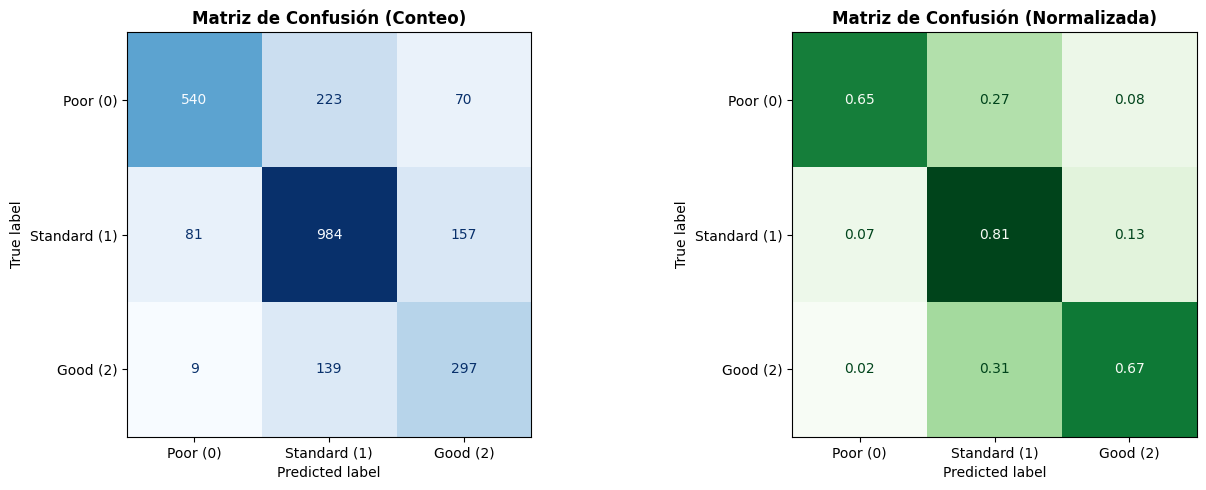

In [30]:
# ── 9.3 Matriz de Confusión ───────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
disp1 = ConfusionMatrixDisplay(cm, display_labels=['Poor (0)', 'Standard (1)', 'Good (2)'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión (Conteo)', fontsize=12, fontweight='bold')

# Valores normalizados
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=['Poor (0)', 'Standard (1)', 'Good (2)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de Confusión (Normalizada)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

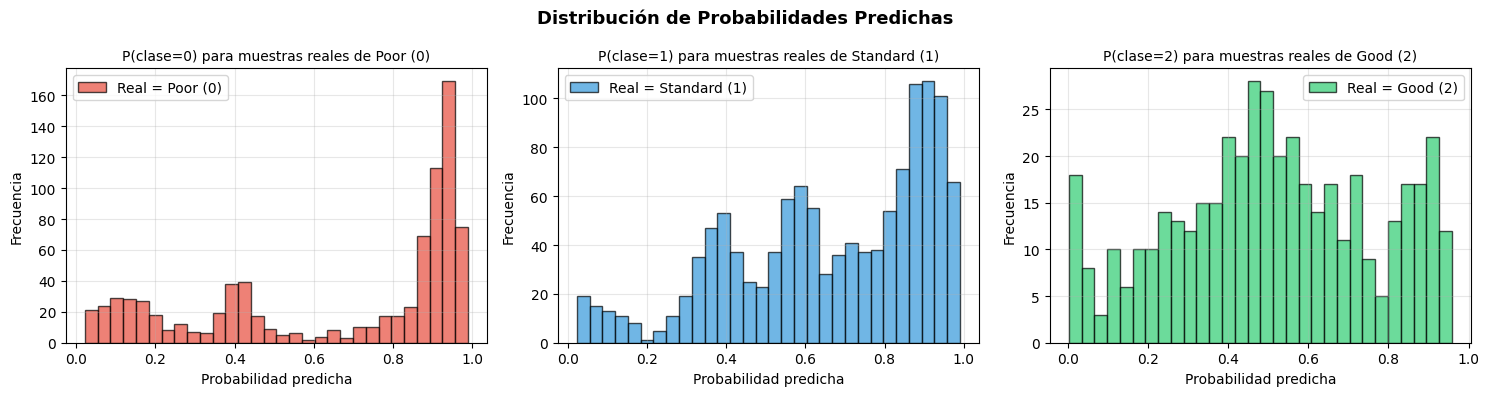

In [31]:
# ── 9.4 Distribución de probabilidades predichas ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clases = ['Poor (0)', 'Standard (1)', 'Good (2)']
colores = ['#e74c3c', '#3498db', '#2ecc71']

for i, (ax, cls, col) in enumerate(zip(axes, clases, colores)):
    mask_real = y_test == i
    ax.hist(y_prob[mask_real, i], bins=30, color=col, alpha=0.7,
            label=f'Real = {cls}', edgecolor='black')
    ax.set_title(f'P(clase={i}) para muestras reales de {cls}', fontsize=10)
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de Probabilidades Predichas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Experimento: Comparación con y sin PCA

In [32]:
# Modelo sin PCA (usando todos los features normalizados)
X_train_full, X_test_full, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model_full = Sequential([
    Dense(128, input_shape=(X_scaled.shape[1],), activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

model_full.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_full = model_full.fit(
    X_train_full, to_categorical(y_train, n_classes),
    validation_split=0.2,
    epochs=150, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=0
)

_, acc_full = model_full.evaluate(X_test_full, to_categorical(y_test, n_classes), verbose=0)
print(f'✅ Accuracy SIN PCA: {acc_full*100:.2f}%')
print(f'✅ Accuracy CON PCA: {test_acc*100:.2f}%')

✅ Accuracy SIN PCA: 72.92%
✅ Accuracy CON PCA: 72.84%


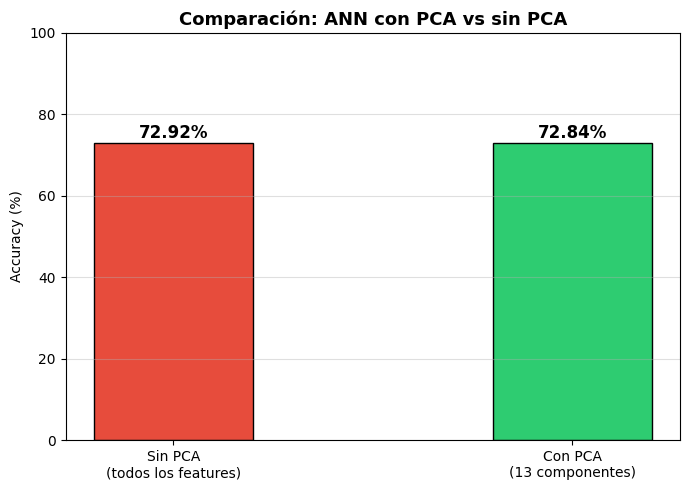

In [33]:
# Comparación visual
modelos = ['Sin PCA\n(todos los features)', f'Con PCA\n({n_components} componentes)']
accuracies = [acc_full * 100, test_acc * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(modelos, accuracies, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Comparación: ANN con PCA vs sin PCA', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Guardar el modelo

In [35]:
# Guardar modelo en formato H5
model.save('ann_credit_score.h5')
print('✅ Modelo guardado como ann_credit_score.h5')

# Guardar modelo en formato Keras nativo (versión nueva)
model.save('ann_credit_score.keras')
print('✅ Modelo guardado como ann_credit_score.keras')

✅ Modelo guardado como ann_credit_score.h5
✅ Modelo guardado como ann_credit_score.keras


## 12. Predicción con nuevos datos

In [36]:
# ── Ejemplo de predicción para un nuevo cliente ──────────────────────────────
# Tomar una muestra del test set como ejemplo
muestra_idx = 0
muestra = X_test[[muestra_idx]]   # Shape: (1, n_components)

prob = model.predict(muestra, verbose=0)[0]
clase_pred = np.argmax(prob)
clase_real = y_test[muestra_idx]

labels = {0: 'Poor', 1: 'Standard', 2: 'Good'}

print('🔮 Predicción para muestra de prueba:')
print(f'   Clase real:      {clase_real} ({labels[clase_real]})')
print(f'   Clase predicha:  {clase_pred} ({labels[clase_pred]})')
print(f'   Probabilidades:')
for i, p in enumerate(prob):
    print(f'     {labels[i]:10s}: {p*100:.2f}%')

🔮 Predicción para muestra de prueba:
   Clase real:      1 (Standard)
   Clase predicha:  1 (Standard)
   Probabilidades:
     Poor      : 38.01%
     Standard  : 58.92%
     Good      : 3.07%


---
## 📋 Resumen del Taller

| Paso | Descripción |
|------|-------------|
| **1. Datos** | Dataset cargado desde GitHub con variables financieras de clientes |
| **2. Limpieza** | Eliminación de columnas irrelevantes (Customer_ID, SSN, Name) |
| **3. Encoding** | LabelEncoder para variables categóricas |
| **4. Normalización** | StandardScaler (media=0, std=1) |
| **5. PCA** | Reducción de dimensionalidad al 95% de varianza |
| **6. ANN** | Red con capas Dense + BatchNormalization + Dropout |
| **7. Salida** | Softmax (3 neuronas para 3 clases) |
| **8. Loss** | Categorical Crossentropy |
| **9. Callbacks** | EarlyStopping + ReduceLROnPlateau |

### Clases de Credit Score:
- **0 → Poor**: Alto riesgo crediticio
- **1 → Standard**: Riesgo crediticio medio
- **2 → Good**: Bajo riesgo crediticio

In [43]:
import joblib
import shutil

ruta = r'C:\Users\maria\Desktop\Taller1'

joblib.dump(scaler, ruta + r'\scaler.pkl')
joblib.dump(pca,    ruta + r'\pca.pkl')
shutil.copy('ann_credit_score.h5', ruta + r'\ann_credit_score.h5')

print('✅ Archivos guardados en Taller1')

✅ Archivos guardados en Taller1


In [44]:
import os
print(os.getcwd())  # Ver dónde está guardando los archivos
print(os.listdir('.'))  # Ver qué archivos hay ahí

/content
['.config', 'pca.pkl', 'ann_credit_score.keras', 'ann_credit_score.h5', 'scaler.pkl', 'C:\\Users\\maria\\Desktop\\Taller1\\scaler.pkl', 'C:\\Users\\maria\\Desktop\\Taller1\\ann_credit_score.h5', 'C:\\Users\\maria\\Desktop\\Taller1\\pca.pkl', 'sample_data']


In [45]:
import joblib

# Guardar con ruta de Windows con doble backslash
joblib.dump(scaler, 'C:\\Users\\maria\\Desktop\\Taller1\\scaler.pkl')
joblib.dump(pca, 'C:\\Users\\maria\\Desktop\\Taller1\\pca.pkl')

import shutil
shutil.copy('ann_credit_score.h5', 'C:\\Users\\maria\\Desktop\\Taller1\\ann_credit_score.h5')

print('✅ Listo')

✅ Listo


In [46]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
print('✅ Listo')

✅ Listo
